<a href="https://colab.research.google.com/github/semanrbingl/ai-ecommerce-product-generator/blob/main/notebooks/03_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)

Kullanılan cihaz: cuda


In [2]:
import kagglehub
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
DATA_DIR = path
print(DATA_DIR)

Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
/kaggle/input/fashion-product-images-small


In [3]:
import os
import pandas as pd

df = pd.read_csv(os.path.join(DATA_DIR, "styles.csv"), on_bad_lines="skip")
df["image_path"] = df["id"].astype(str).apply(
    lambda x: os.path.join(DATA_DIR, "images", x + ".jpg")
)
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

TOP_N = 20
MIN_SAMPLES = 500
counts = df["articleType"].value_counts()
raw_counts = counts.head(TOP_N)
top_classes = raw_counts[raw_counts >= MIN_SAMPLES].index.tolist()

df_model = df[df["articleType"].isin(top_classes)].reset_index(drop=True).copy()

class_names = sorted(df_model["articleType"].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

df_model["label"] = df_model["articleType"].map(class_to_idx)

print("Sınıf sayısı:", len(class_names))
print("Toplam görsel:", len(df_model))

Sınıf sayısı: 20
Toplam görsel: 33142


In [4]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_model, test_size=0.30, stratify=df_model["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 23199
Validation: 4971
Test: 4972


google drive'dan 02-notebook modeli geri yükleme

In [5]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/ai_ecommerce_product_generator"
checkpoint_path = os.path.join(SAVE_DIR, "baseline_resnet50.pth")

checkpoint = torch.load(checkpoint_path, map_location=device)
print(checkpoint.keys())

Mounted at /content/drive
dict_keys(['model_state_dict', 'class_to_idx', 'idx_to_class'])


In [7]:
# Burada sadece ResNet50'nin boş iskeletini kuruyoruz (weights=None).
# ImageNet ağırlıkları yok, çünkü kendi eğittiğimiz ağırlıkları
# birazdan load_state_dict ile elle dolduracağız.

from torchvision import models
import torch.nn as nn

num_classes = len(checkpoint["class_to_idx"])

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Model yüklendi, sınıf sayısı:", num_classes)

Model yüklendi, sınıf sayısı: 20


In [8]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

class ProductImageDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, index):
    row = self.dataframe.iloc[index]
    image = Image.open(row["image_path"]).convert("RGB")
    label = row["label"]
    if self.transform:
      image = self.transform(image)
    return image, label

test_dataset = ProductImageDataset(test_df, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Test görsel sayısı:", len(test_dataset))

Test görsel sayısı: 4972


In [9]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    confidence, preds = torch.max(probs, 1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.numpy())
    all_probs.extend(confidence.cpu().numpy())

print("Toplanan tahmin sayısı:", len(all_preds))

Toplanan tahmin sayısı: 4972


In [10]:
results_df = test_df.reset_index(drop=True).copy()
results_df["true_label"] = all_labels
results_df["pred_label"] = all_preds
results_df["confidence"] = all_probs

results_df["true_class"] = results_df["true_label"].map(idx_to_class)
results_df["pred_class"] = results_df["pred_label"].map(idx_to_class)
results_df["correct"] = results_df["true_class"] == results_df["pred_class"]

results_df[["articleType", "true_class", "pred_class", "confidence", "correct"]].head(10)

,articleType,true_class,pred_class,confidence,correct
0,Handbags,Handbags,Handbags,0.999949,True
1,Heels,Heels,Heels,0.958982,True
2,Watches,Watches,Watches,0.999962,True
3,Shirts,Shirts,Shirts,0.944720,True
4,Casual Shoes,Casual Shoes,Formal Shoes,0.723070,False
5,Heels,Heels,Heels,0.884011,True
6,Watches,Watches,Watches,0.999726,True
7,Sports Shoes,Sports Shoes,Sports Shoes,0.920294,True
8,Socks,Socks,Socks,0.991171,True
9,Tshirts,Tshirts,Tshirts,0.688500,True


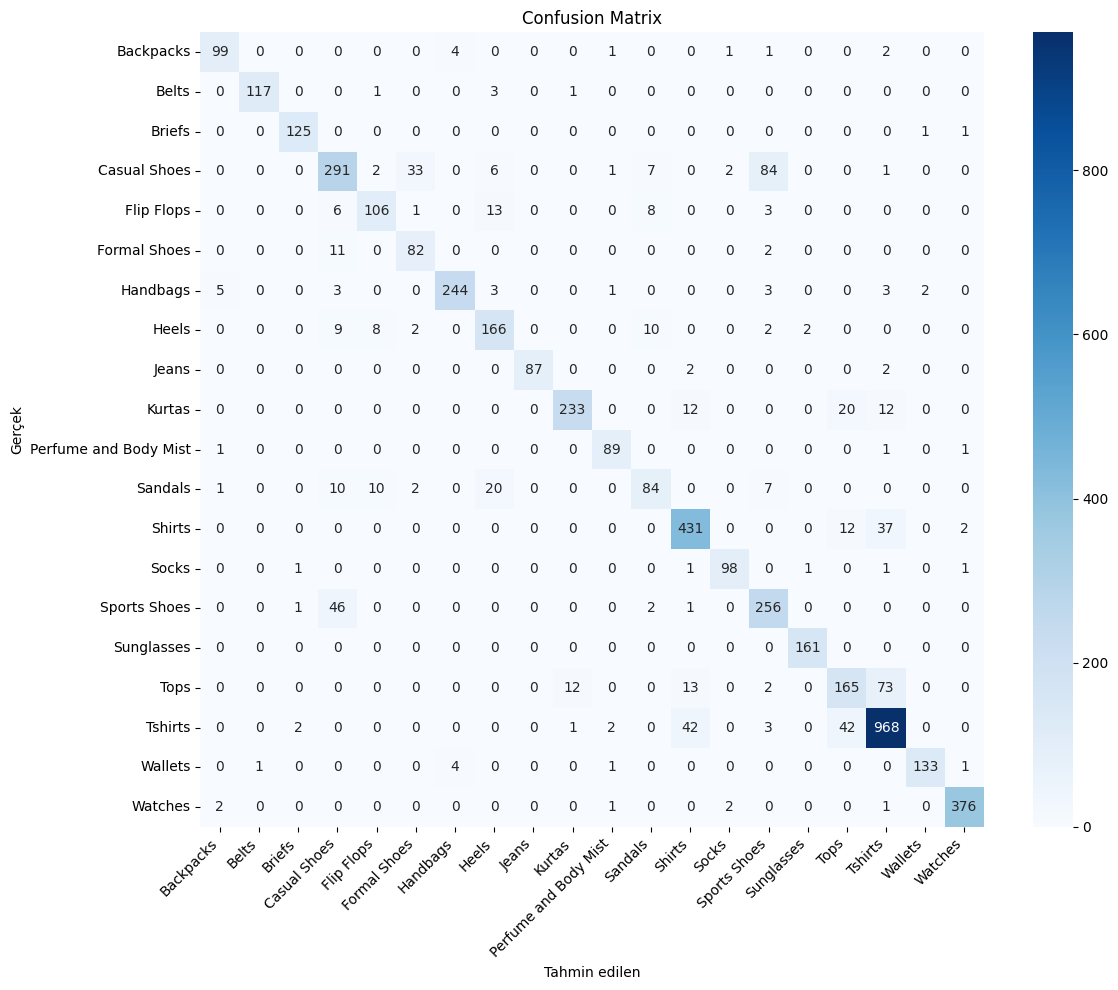

In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(results_df["true_class"], results_df["pred_class"], labels=class_names)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Tahmin edilen")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import classification_report

report = classification_report(
    results_df["true_class"], results_df["pred_class"],
    target_names=class_names, output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df.round(3)

,precision,recall,f1-score,support
Backpacks,0.917,0.917,0.917,108.000
Belts,0.992,0.959,0.975,122.000
Briefs,0.969,0.984,0.977,127.000
Casual Shoes,0.774,0.681,0.725,427.000
Flip Flops,0.835,0.774,0.803,137.000
Formal Shoes,0.683,0.863,0.763,95.000
Handbags,0.968,0.924,0.946,264.000
Heels,0.787,0.834,0.810,199.000
Jeans,1.000,0.956,0.978,91.000
Kurtas,0.943,0.841,0.889,277.000


ÖZET

Model, görsel olarak belirgin kategorilerde (Sunglasses, Watches, Jeans) %97-99 f1-score'a ulaşırken,
birbirine benzeyen kategorilerde (Casual/Sports Shoes, Tops/Kurtas/Tshirts, Sandals/Flip Flops)
%65-73 aralığında kalıyor. Hatalar rastgele değil, görsel olarak benzer sınıflar arasında yoğunlaşıyor.

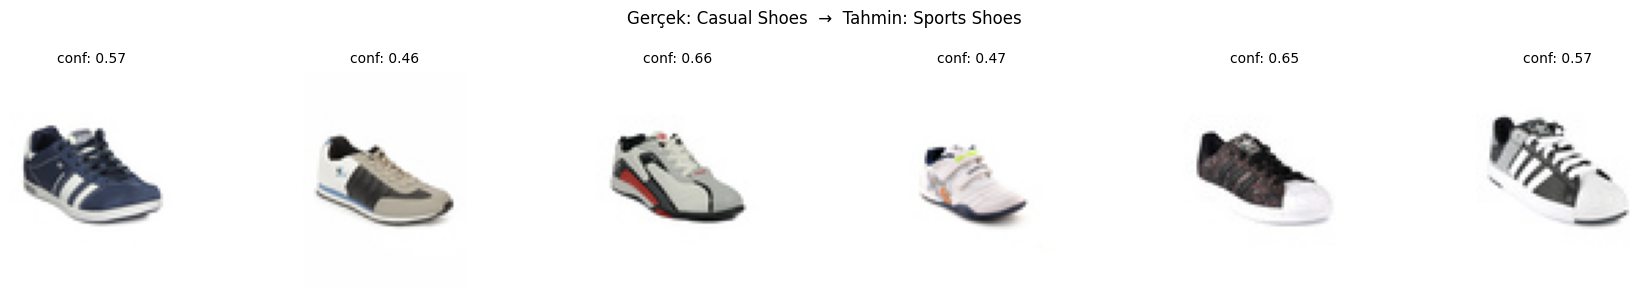

In [13]:
def show_confusions(results_df, true_cls, pred_cls, n=6):
  subset = results_df[
      (results_df["true_class"] == true_cls) &
      (results_df["pred_class"] == pred_cls)
  ]
  n = min(n, len(subset))
  if n == 0:
         print(f"{true_cls} -> {pred_cls} için örnek yok")
         return

  sample = subset.sample(n, random_state=42)
  fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
  if n == 1:
      axes = [axes]


  for ax, (_, row) in zip(axes, sample.iterrows()):
        ax.imshow(Image.open(row["image_path"]).convert("RGB"))
        ax.axis("off")
        ax.set_title(f"conf: {row['confidence']:.2f}", fontsize=10)

  fig.suptitle(f"Gerçek: {true_cls}  →  Tahmin: {pred_cls}", fontsize=12)
  plt.tight_layout()
  plt.show()

show_confusions(results_df, "Casual Shoes", "Sports Shoes", n=6)

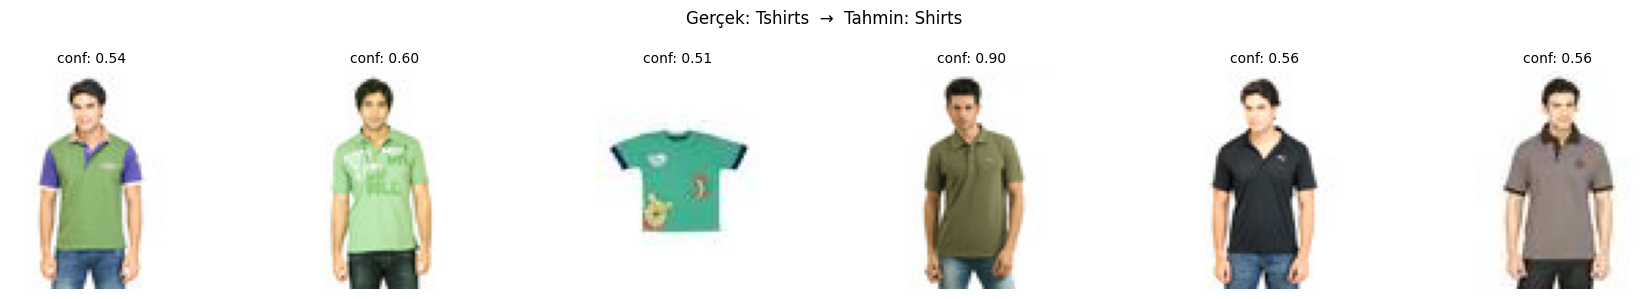

In [14]:
show_confusions(results_df, "Tshirts", "Shirts", n=6)

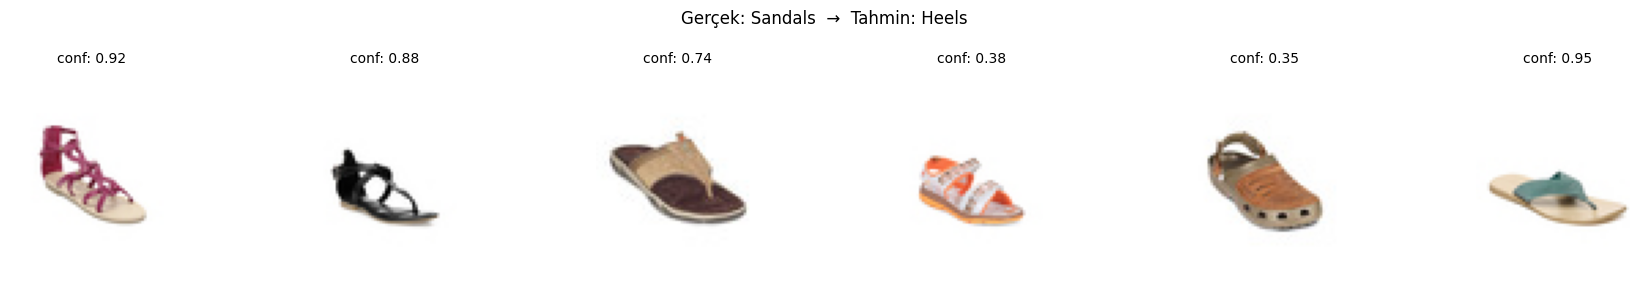

In [16]:
show_confusions(results_df, "Sandals", "Heels", n=6)

ÖZET

Test accuracy %86.7, macro f1 0.875.

**Güçlü sınıflar:** Sunglasses, Jeans, Watches (f1 > 0.95) — görsel olarak belirgin.

**Zayıf sınıflar:** Tops, Sandals, Casual Shoes (f1 < 0.75) — benzer kategorilerle karışıyor.

**Üç dikkat çekici karışıklık:**
- Casual Shoes ↔ Sports Shoes: gerçek görsel benzerlik.
- Tshirts ↔ Shirts: polo yaka ürünlerde etiketleme belirsizliği.
- Sandals → Heels: model %88-95 gibi yüksek güvenle yanılıyor, nedeni Aşama 4'te (Grad-CAM) incelenecek.

**Sonuç:** Hatalar rastgele değil, görsel benzerlik veya etiket belirsizliği olan yerlerde yoğunlaşıyor.